# 13. Polynomial Root Finding

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. Say what extra structure a polynomial has, and what that structure buys.
2. Use **Descartes' rule of signs** to bound the number of positive and negative roots for free.
3. Use a **Sturm sequence** to count the real roots in an interval **exactly**.
4. Bound where all the roots live with the **Cauchy bound**.
5. Implement **Birge-Vieta**, Newton driven by synthetic division.
6. Use **deflation** to find every root, and demonstrate the error growth that makes it
   dangerous.
7. Use **Bairstow's method** to find complex conjugate pairs without leaving real arithmetic.
8. Explain why **Graeffe root squaring** is elegant and unusable.
9. Explain the **companion matrix** approach, which is what `numpy.roots` actually does.

## Prerequisites

Lesson 01 (Horner and synthetic division), lesson 11 (Newton), and above all **lesson 12**,
which showed that coefficients are a badly conditioned description of roots. Every method here
works with coefficients, so that warning applies throughout.

---

## 1. What a polynomial gives you that a general function does not

For a general $f$ you know almost nothing before you start. For

$$p(x) = a_0x^n + a_1x^{n-1} + \cdots + a_n$$

you know a great deal:

| Structure | What it buys |
|---|---|
| **Degree $n$** | exactly $n$ roots in $\mathbb{C}$, counted with multiplicity, by the fundamental theorem of algebra |
| **Finite coefficient data** | you can reason about the roots without evaluating anything |
| **Real coefficients** | complex roots come in conjugate pairs, so finding one gives two |
| **Closed under division** | dividing out a known root leaves a polynomial, so you can recurse |
| **Cheap derivatives** | $p'$ is a polynomial of degree $n-1$, and Horner gives it for free |

Every method in this lesson exploits at least one of those. None of them is available to the
methods in lessons 09 to 11.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import polyroots as pr, polynomials as poly, roots as R

# p(x) = (x-1)(x-2)(x-3), expanded
p = poly.from_roots([1.0, 2.0, 3.0])
print("p(x) = (x-1)(x-2)(x-3) has coefficients", p)
print(f"degree {len(p)-1}, so exactly {len(p)-1} roots in the complex plane")
print(f"p'(x) coefficients: {poly.derivative_coeffs(p)}, degree {len(p)-2}")

p(x) = (x-1)(x-2)(x-3) has coefficients [ 1. -6. 11. -6.]
degree 3, so exactly 3 roots in the complex plane
p'(x) coefficients: [  3. -12.  11.], degree 2


## 2. Counting before searching: Descartes' rule of signs

> **Theorem 13.1 (Descartes).** The number of positive real roots of $p$, counted with
> multiplicity, equals the number of sign changes in its coefficient sequence, or is less than
> that by an even number. Applying the rule to $p(-x)$ bounds the negative roots.

This costs **zero function evaluations**. You read it off the coefficients.

In [3]:
cases = [
    ("(x-1)(x-2)(x-3)",     poly.from_roots([1.0, 2.0, 3.0])),
    ("(x+1)(x+2)(x+3)",     poly.from_roots([-1.0, -2.0, -3.0])),
    ("(x-1)(x+2)(x-3)",     poly.from_roots([1.0, -2.0, 3.0])),
    ("x^2 + 1",             np.array([1.0, 0.0, 1.0])),
    ("x^4 + 1",             np.array([1.0, 0.0, 0.0, 0.0, 1.0])),
]

print(f"{'polynomial':>20} {'deg':>4} {'positive roots':>18} {'negative roots':>18} "
      f"{'actual real':>12}")
print("-" * 78)
for name, c in cases:
    d = pr.descartes_bounds(c)
    actual = int(np.sum(np.abs(np.roots(c).imag) < 1e-12))
    print(f"{name:>20} {d['degree']:>4} {str(d['positive']):>18} "
          f"{str(d['negative']):>18} {actual:>12}")

print()
print("row 4: x^2+1 has 0 sign changes either way, so NO real roots at all.")
print("row 5: same for x^4+1. that is certain knowledge, obtained for free,")
print("before evaluating the polynomial even once.")

d4 = pr.descartes_bounds(np.array([1.0, 0.0, 1.0]))
assert d4["positive"] == [0] and d4["negative"] == [0]

          polynomial  deg     positive roots     negative roots  actual real
------------------------------------------------------------------------------
     (x-1)(x-2)(x-3)    3             [3, 1]                [0]            3
     (x+1)(x+2)(x+3)    3                [0]             [3, 1]            3
     (x-1)(x+2)(x-3)    3             [2, 0]                [1]            3
             x^2 + 1    2                [0]                [0]            0
             x^4 + 1    4                [0]                [0]            0

row 4: x^2+1 has 0 sign changes either way, so NO real roots at all.
row 5: same for x^4+1. that is certain knowledge, obtained for free,
before evaluating the polynomial even once.


The rule gives a **bound**, not a count. The first row says "3 or 1 positive roots" and cannot
narrow it further. For the exact number we need something stronger.

## 3. Counting exactly: Sturm sequences

Sturm's theorem is one of the more remarkable results in elementary algebra. It gives the
**exact** number of distinct real roots in any interval, with no sampling and no possibility of
missing a root however narrowly spaced.

Build the chain by a signed Euclidean algorithm:

$$p_0 = p, \qquad p_1 = p', \qquad p_{k+1} = -\operatorname{rem}(p_{k-1}, p_k),$$

stopping when the remainder is constant.

> **Theorem 13.2 (Sturm).** Let $V(x)$ be the number of sign changes in
> $p_0(x), p_1(x), \dots$, ignoring zeros. If $p$ is squarefree and $p(a)p(b) \ne 0$, the
> number of **distinct** real roots in $(a, b]$ is exactly $V(a) - V(b)$.

In [4]:
p5 = poly.from_roots([-2.0, 0.5, 1.0, 3.0, 7.0])
chain = pr.sturm_sequence(p5)

print("p(x) = (x+2)(x-0.5)(x-1)(x-3)(x-7)")
print(f"Sturm chain has {len(chain)} polynomials, of degrees "
      f"{[len(c)-1 for c in chain]}")
print()
print(f"{'interval':>18} {'sign changes at a':>19} {'at b':>7} {'root count':>12} "
      f"{'true':>6}")
print("-" * 68)
true_roots = np.array([-2.0, 0.5, 1.0, 3.0, 7.0])
for a, b in [(-10, 10), (0, 10), (0, 2), (0.75, 5), (1.5, 2.5), (-3, 0)]:
    count = pr.sturm_count(p5, a, b)
    true = int(np.sum((true_roots > a) & (true_roots <= b)))
    print(f"{f'({a}, {b}]':>18} {pr.sturm_sign_changes(chain, a):>19} "
          f"{pr.sturm_sign_changes(chain, b):>7} {count:>12} {true:>6}")
    assert count == true, f"Sturm count wrong on ({a},{b}]"

print()
print("every count is exact. (1.5, 2.5] contains no roots, and Sturm knows it")
print("without evaluating p anywhere inside.")

p(x) = (x+2)(x-0.5)(x-1)(x-3)(x-7)
Sturm chain has 6 polynomials, of degrees [5, 4, 3, 2, 1, 0]

          interval   sign changes at a    at b   root count   true
--------------------------------------------------------------------
         (-10, 10]                   5       0            5      5
           (0, 10]                   4       0            4      4
            (0, 2]                   4       2            2      2
         (0.75, 5]                   3       1            2      2
        (1.5, 2.5]                   2       2            0      0
           (-3, 0]                   5       4            1      1

every count is exact. (1.5, 2.5] contains no roots, and Sturm knows it
without evaluating p anywhere inside.


### Why this matters: isolating every root

Sturm counting turns root finding into a **reliable** procedure. Bisect on the *count* rather
than on the sign: keep splitting any interval whose count exceeds 1, until every root sits alone
in its own bracket. Then hand each bracket to Brent.

No root can be missed, no matter how close two of them are.

In [5]:
def isolate_roots(coeffs, lo, hi, depth=40):
    """Split until every subinterval holds at most one root. Returns the brackets."""
    out, stack = [], [(float(lo), float(hi), 0)]
    while stack:
        a, b, d = stack.pop()
        k = pr.sturm_count(coeffs, a, b)
        if k == 0:
            continue
        if k == 1 or d >= depth:
            out.append((a, b))
            continue
        m = a + (b - a) / 2
        stack.append((a, m, d + 1))
        stack.append((m, b, d + 1))
    return sorted(out)


bound = pr.cauchy_bound(p5)
print(f"Cauchy bound: all roots satisfy |r| <= {bound:.2f}\n")

brackets = isolate_roots(p5, -bound, bound)
print(f"isolated {len(brackets)} brackets, one root each:")
for a, b in brackets:
    r = R.brent(lambda x: np.polyval(p5, x), a, b, tol=1e-15)
    print(f"   ({a:>9.4f}, {b:>9.4f}]  ->  root {r.root:.14f}")

found = sorted(R.brent(lambda x: np.polyval(p5, x), a, b, tol=1e-15).root
               for a, b in brackets)
assert len(found) == 5
np.testing.assert_allclose(found, true_roots, atol=1e-12)
print("\nall five roots found, none missed, each to 12 digits.")
print("no other procedure in this course can promise it found them all.")

Cauchy bound: all roots satisfy |r| <= 63.50

isolated 5 brackets, one root each:
   ( -63.5000,    0.0000]  ->  root -2.00000000000000
   (   0.0000,    0.9922]  ->  root 0.50000000000000
   (   0.9922,    1.9844]  ->  root 1.00000000000000
   (   1.9844,    3.9688]  ->  root 3.00000000000000
   (   3.9688,    7.9375]  ->  root 7.00000000000000

all five roots found, none missed, each to 12 digits.
no other procedure in this course can promise it found them all.


### But the theorem is exact, and the arithmetic is not

Sturm's theorem is exact in **exact** arithmetic. Building the chain in floating point is a
different matter: it needs repeated polynomial remainders, and every division loses accuracy. So
there is a gap below which the computed chain can no longer tell two nearby roots apart.

That limit is worth measuring rather than assuming.

In [6]:
print("two roots at 1 and 1+gap, plus a distant root at 5.")
print("how small a gap can each method resolve?")
print()
print(f"{'gap':>10} {'Sturm count in (0,3]':>22} {'numpy.roots real count':>24}")
print("-" * 62)

resolved, lost = [], []
for gap in [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]:
    c = poly.from_roots([1.0, 1.0 + gap, 5.0])
    k = pr.sturm_count(c, 0.0, 3.0)
    n_real = int(np.sum(np.abs(np.roots(c).imag) < 1e-14))
    flag = "" if k == 2 else "   <-- wrong"
    (resolved if k == 2 else lost).append(gap)
    print(f"{gap:>10.0e} {k:>22} {n_real:>24}{flag}")

print()
print(f"Sturm resolves gaps down to about {min(resolved):.0e} and fails below that.")
print("the companion matrix keeps three real roots considerably further down.")
print()
print("this does NOT contradict the theorem. it says the CHAIN is fragile in")
print("floating point, because polynomial remainders amplify error. an exact")
print("count, computed by an inexact procedure.")
print()
print("lesson 12 gives the floor that nobody can beat: a nearly double root has")
print(f"condition u^(1/2), about {np.sqrt(np.finfo(float).eps/2):.1e}, so no method can")
print("resolve gaps below that from the coefficients. Sturm gives up earlier.")

assert min(resolved) <= 1e-3
assert max(lost) >= 1e-5

two roots at 1 and 1+gap, plus a distant root at 5.
how small a gap can each method resolve?

       gap   Sturm count in (0,3]   numpy.roots real count
--------------------------------------------------------------
     1e-01                      2                        3
     1e-02                      2                        3
     1e-03                      2                        3
     1e-04                      2                        3
     1e-05                      1                        3   <-- wrong
     1e-06                      1                        3   <-- wrong
     1e-07                      1                        3   <-- wrong
     1e-08                      1                        3   <-- wrong

Sturm resolves gaps down to about 1e-04 and fails below that.
the companion matrix keeps three real roots considerably further down.

this does NOT contradict the theorem. it says the CHAIN is fragile in
floating point, because polynomial remainders amplify error

**What to take from this.** Sturm is the right tool for isolating roots that are separated on the
scale of the problem, which is the usual case, and it is the only tool that can *prove* it found
them all. It is not a way around lesson 12's conditioning, and its floating point implementation
gives out before that limit is even reached. If you need the theorem's exactness, build the chain
in exact rational arithmetic.

## 4. Birge-Vieta: Newton with synthetic division

Newton needs $p$ and $p'$. For a polynomial, one pass of synthetic division gives $p(x)$, and
running the same recurrence on the intermediate quotients gives $p'(x)$ at no extra cost. That
is lesson 01's `horner_with_derivative`, and using it inside Newton is called the **Birge-Vieta**
or Newton-Horner method.

```text
BIRGE_VIETA(a[0..n], x0, tol)
    x <- x0
    repeat:
        # one pass computes both p(x) and p'(x)
        p <- a[0];  dp <- 0
        for k = 1 to n:
            dp <- dp*x + p
            p  <- p*x + a[k]
        if dp = 0: fail
        x <- x - p/dp
        if |p/dp| <= tol: return x
```

The inner loop is four arithmetic operations per coefficient, and it produces value and slope
together. There is no cheaper way to run Newton on a polynomial.

In [7]:
def birge_vieta_teaching(coeffs, x0, tol=1e-14, max_iter=100):
    """Newton on a polynomial. One synthetic division gives both p and p'."""
    a = list(coeffs)
    x, xs = float(x0), [float(x0)]
    for _ in range(max_iter):
        p, dp = a[0], 0.0
        for ak in a[1:]:
            dp = dp * x + p          # derivative uses the PREVIOUS p
            p = p * x + ak
        if dp == 0.0:
            break
        step = p / dp
        x -= step
        xs.append(x)
        if abs(step) <= tol:
            break
    return x, np.array(xs)


root, hist = birge_vieta_teaching(p5, 5.0)
lib = pr.birge_vieta(p5, 5.0)

print(f"starting from x0 = 5.0 on the degree 5 polynomial:")
print(f"   from scratch : {root:.16f}")
print(f"   nalib        : {lib['root']:.16f}")
print(f"   iterations   : {len(hist) - 1}")
print(f"   residual     : {abs(np.polyval(p5, root)):.3e}")
print(f"   path         : {np.array2string(hist, precision=4)}")

np.testing.assert_allclose(hist, lib["iterates"])
assert abs(np.polyval(p5, root)) < 1e-10, "it should land on a genuine root"
nearest_true = true_roots[np.argmin(np.abs(true_roots - root))]
assert abs(root - nearest_true) < 1e-10

print(f"\nit converged to the root at {nearest_true:g}. note that the NEAREST root to")
print("the starting point 5.0 was 7, and Newton went the other way.")
print("that is the lesson 11 warning again: Newton converges fast, and it gives")
print("you no control at all over WHICH root you get. for polynomials that")
print("matters more than usual, because you generally want all of them.")

starting from x0 = 5.0 on the degree 5 polynomial:
   from scratch : 3.0000000000000000
   nalib        : 3.0000000000000000
   iterations   : 7
   residual     : 0.000e+00
   path         : [5.     3.3742 3.0758 3.0044 3.     3.     3.     3.    ]

it converged to the root at 3. note that the NEAREST root to
the starting point 5.0 was 7, and Newton went the other way.
that is the lesson 11 warning again: Newton converges fast, and it gives
you no control at all over WHICH root you get. for polynomials that
matters more than usual, because you generally want all of them.


## 5. Deflation, and why the order matters

Once a root $r$ is found, divide it out: $p(x) = (x - r)\,q(x)$. The remaining roots are the
roots of $q$, which has degree one lower. Repeat until nothing is left.

This is the natural way to get **all** the roots, and it is where polynomials repay their
structure. It also carries a real danger.

> **The problem with deflation.** Each computed root carries error. Dividing by
> $(x - \hat{r})$ instead of $(x - r)$ produces a $q$ whose coefficients are slightly wrong, so
> the *next* root is found from already-corrupted data. Errors compound.

The standard mitigation has two parts, and both matter:

1. **Find roots in increasing order of magnitude.** Dividing out a small root perturbs the
   remaining coefficients less than dividing out a large one.
2. **Polish** every root at the end with a Newton step on the **original** polynomial.

In [8]:
print("deflation on (x-1)(x-2)...(x-n), finding roots in two different orders\n")
print(f"{'n':>3} {'order':>14} {'roots found':>12} {'raw error':>12} "
      f"{'polished error':>16}")
print("-" * 62)

for n in [6, 10]:
    true = np.arange(1.0, n + 1)
    c = poly.from_roots(true)
    for label, start in [("small first", 0.0), ("large first", float(n) + 2)]:
        res = pr.all_roots_by_deflation(c, start=start)
        if res["n_found"] == n:
            raw = np.abs(np.sort(res["raw"]) - true).max()
            pol = np.abs(np.sort(res["polished"]) - true).max()
            print(f"{n:>3} {label:>14} {res['n_found']:>12} {raw:>12.2e} "
                  f"{pol:>16.2e}")
        else:
            print(f"{n:>3} {label:>14} {res['n_found']:>12} "
                  f"{'BROKE DOWN':>12} {'':>16}")

print()
print("at n = 6 the wrong order costs a factor of ten in accuracy.")
print("at n = 10 the wrong order does not merely lose accuracy: the deflated")
print("polynomial becomes so corrupted that the iteration stops finding roots")
print("at all, and only 2 of the 10 are recovered.")

bad = pr.all_roots_by_deflation(poly.from_roots(np.arange(1.0, 11.0)), start=12.0)
assert bad["n_found"] < 10, "large-first deflation should break down at degree 10"

deflation on (x-1)(x-2)...(x-n), finding roots in two different orders

  n          order  roots found    raw error   polished error
--------------------------------------------------------------
  6    small first            6     8.53e-14         1.52e-13
  6    large first            6     8.57e-13         3.08e-13
 10    small first           10     2.06e-10         2.59e-10
 10    large first            2   BROKE DOWN                 

at n = 6 the wrong order costs a factor of ten in accuracy.
at n = 10 the wrong order does not merely lose accuracy: the deflated
polynomial becomes so corrupted that the iteration stops finding roots
at all, and only 2 of the 10 are recovered.


Two rows of a table are easy to dismiss. The trend across degrees is not.

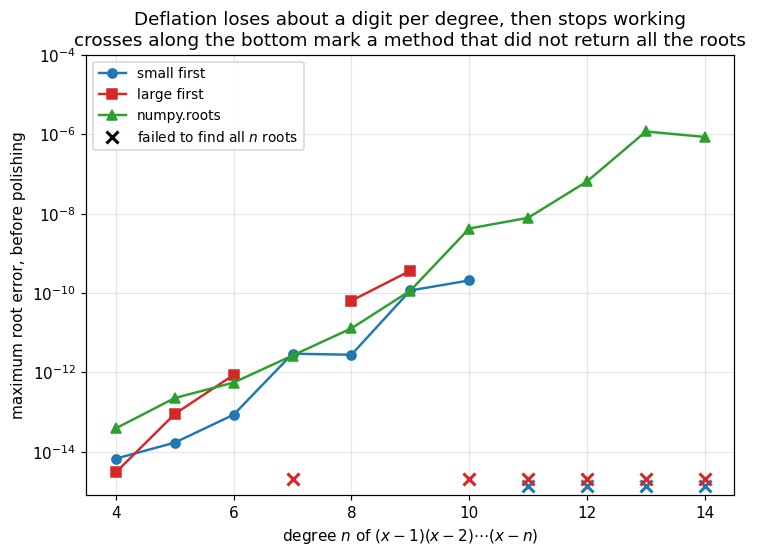

degrees 4 to 14, which ones each method solved completely:
    small first:  7 of 11   [4, 5, 6, 7, 8, 9, 10]
    large first:  5 of 11   [4, 5, 6, 8, 9]
    numpy.roots: 11 of 11   [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

small-first error grows by 10^0.81 per degree, so about 0.8 digits lost per degree.


In [9]:
u = np.finfo(float).eps / 2
degrees = list(range(4, 15))
series = {"small first": [], "large first": [], "numpy.roots": []}

for n in degrees:
    true = np.arange(1.0, n + 1)
    c = poly.from_roots(true)
    series["numpy.roots"].append(np.abs(np.sort(np.roots(c).real) - true).max())
    for label, start in [("small first", 0.0), ("large first", float(n) + 2)]:
        res = pr.all_roots_by_deflation(c, start=start)
        if res["n_found"] == n:
            series[label].append(np.abs(np.sort(np.real(res["raw"])) - true).max())
        else:
            series[label].append(np.nan)          # did not find all the roots

fig, ax = plt.subplots(figsize=(7.6, 5.2))
styles = {"small first": ("C0", "o-"), "large first": ("C3", "s-"),
          "numpy.roots": ("C2", "^-")}

FLOOR = 3e-15          # an exact hit is 0, which is -infinity on a log axis
for row, (label, vals) in enumerate(series.items()):
    colour, marker = styles[label]
    v = np.array(vals, dtype=float)
    ax.semilogy(degrees, np.maximum(v, FLOOR), marker, color=colour, ms=6, lw=1.6,
                label=label)
    # mark the degrees where this method failed to return all n roots,
    # on its own row so overlapping failures stay visible
    y_row = 1.35e-15 * (1.55 ** row)
    for d, bad in zip(degrees, np.isnan(v)):
        if bad:
            ax.plot(d, y_row, "x", color=colour, ms=8, mew=2)

ax.plot([], [], "kx", ms=8, mew=2, label="failed to find all $n$ roots")
ax.set_xlabel("degree $n$ of $(x-1)(x-2)\\cdots(x-n)$")
ax.set_ylabel("maximum root error, before polishing")
ax.set_title("Deflation loses about a digit per degree, then stops working\n"
             "crosses along the bottom mark a method that did not return all the roots")
ax.set_ylim(8e-16, 1e-4)
ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.3, which="both")
plt.show()

alive = {k: [d for d, x in zip(degrees, v) if not np.isnan(x)]
         for k, v in series.items()}
print("degrees 4 to 14, which ones each method solved completely:")
for k, v in alive.items():
    print(f"   {k:>12}: {len(v):>2} of {len(degrees)}   {v}")

sm = np.array(series["small first"], dtype=float)
good = ~np.isnan(sm)
slope = np.polyfit(np.array(degrees)[good], np.log10(np.maximum(sm[good], u)), 1)[0]
print(f"\nsmall-first error grows by 10^{slope:.2f} per degree, "
      f"so about {slope:.1f} digits lost per degree.")

assert len(alive["small first"]) > len(alive["large first"])
assert len(alive["numpy.roots"]) == len(degrees)
assert slope > 0.5

**What to take from this.** Three things the plot shows that the two-row table does not.

**Deflation degrades steadily, not suddenly.** The fitted slope says it loses about three
quarters of a digit for every extra degree. That is the compounding of section 5 made visible,
and it means the method has a usable range rather than a hard limit.

**The failure is by breakdown, not by inaccuracy.** Look at the crosses. Large-first fails
outright at degree 7, works again at 8 and 9, then fails from 10 onwards. Small-first works
through degree 10 and fails from 11. When deflation goes wrong it does not return a bad answer,
it returns **fewer roots than the polynomial has**, because the corrupted deflated polynomial no
longer has the real roots the iteration is looking for. That is a better failure mode than
silently wrong output, and it is the one thing deflation has in its favour.

**Where both orders work, they are closer than you might expect.** Small-first is typically 3 to
10 times more accurate in raw error, not the orders of magnitude the compounding argument might
suggest, and after polishing the gap narrows further. The order matters most for **whether the
method survives at all**, and only secondarily for accuracy.

The companion matrix never breaks down over this range. Its error grows at a similar rate,
because it faces the same conditioning, but it always returns $n$ roots. Both approaches are
beaten by the conditioning in the end. Only one of them keeps working while it loses accuracy,
and that is why `numpy.roots` uses it.

**This is lesson 12 arriving on schedule.** Deflation repeatedly rewrites the coefficients, and
coefficients are the badly conditioned representation. Every division makes the remaining
problem worse conditioned than the one you started with.

## 6. Bairstow: complex pairs without complex arithmetic

A real polynomial's complex roots come in conjugate pairs $\alpha \pm i\beta$, and each pair
corresponds to a **real quadratic factor**

$$x^2 - rx - s, \qquad r = 2\alpha, \quad s = -(\alpha^2+\beta^2).$$

So instead of dividing by a linear factor, divide by a quadratic. If the remainder can be driven
to zero, a whole conjugate pair falls out, and **every number involved stays real**.

Lesson 11's Muller reached complex roots by going complex. Bairstow reaches them without ever
leaving the reals, which mattered enormously on machines without complex arithmetic and still
matters when you want to keep a real code path.

### The method

Divide $p$ by $x^2 - rx - s$ using a synthetic division that carries two terms:

$$b_0 = a_0, \quad b_1 = a_1 + rb_0, \quad b_k = a_k + rb_{k-1} + sb_{k-2}.$$

The remainder is determined by $b_{n-1}$ and $b_n$, and we want both zero. That is two equations
in the two unknowns $r$ and $s$, so apply **Newton's method in two variables**. The partial
derivatives come from running the same recurrence a second time on the $b$ values, exactly the
trick Birge-Vieta uses one dimension down.

In [10]:
tests = [
    ("x^4 + 1",              np.array([1.0, 0, 0, 0, 1.0]),        1.0, -1.0),
    ("(x-2)(x^2+x+1)",       np.polymul([1.0, -2.0], [1.0, 1.0, 1.0]), -1.0, -1.0),
    ("(x^2+4)(x^2+9)",       np.polymul([1.0, 0, 4.0], [1.0, 0, 9.0]),  0.1, -1.0),
]

for name, c, r0, s0 in tests:
    res = pr.bairstow(c, r0, s0)
    print(f"{name}")
    if res["converged"]:
        got = np.array(res["roots"])
        print(f"   quadratic factor : x^2 - ({res['r']:.6f})x - ({res['s']:.6f})")
        print(f"   its roots        : {got[0]:.10f}, {got[1]:.10f}")
        print(f"   residuals        : "
              f"{np.abs(np.polyval(c, got)).max():.2e}")
        print(f"   iterations       : {res['iterations']}")
        assert np.abs(np.polyval(c, got)).max() < 1e-10
    else:
        print(f"   {res['message']}")
    print()

print("every root above was found using only real arithmetic. no complex number")
print("appears until the final quadratic formula is applied to r and s.")

x^4 + 1
   quadratic factor : x^2 - (1.414214)x - (-1.000000)
   its roots        : 0.7071067812+0.7071067812j, 0.7071067812-0.7071067812j
   residuals        : 3.13e-16
   iterations       : 7

(x-2)(x^2+x+1)
   quadratic factor : x^2 - (-1.000000)x - (-1.000000)
   its roots        : -0.5000000000+0.8660254038j, -0.5000000000-0.8660254038j
   residuals        : 2.42e-16
   iterations       : 1

(x^2+4)(x^2+9)
   quadratic factor : x^2 - (0.000000)x - (-4.000000)
   its roots        : 0.0000000000+2.0000000000j, 0.0000000000-2.0000000000j
   residuals        : 0.00e+00
   iterations       : 7

every root above was found using only real arithmetic. no complex number
appears until the final quadratic formula is applied to r and s.


Bairstow inherits Newton's properties, including its failures: it converges quadratically near a
good $(r, s)$, and it can diverge or cycle from a poor start. In practice one retries from
several starting pairs.

## 7. Graeffe root squaring: elegant and unusable

Graeffe's method is worth seeing precisely because it fails, and because the failure is
instructive.

**The idea.** Given $p$ with roots $r_1, \dots, r_n$, construct the polynomial whose roots are
$r_1^2, \dots, r_n^2$. Squaring exaggerates differences in magnitude: if $|r_1| > |r_2|$ then
after $m$ squarings the ratio is $(|r_1|/|r_2|)^{2^m}$, which is enormous. Once the roots are
separated by many orders of magnitude, the coefficients of the squared polynomial essentially
*are* the roots:

$$|r_k| \;\approx\; \left|\frac{b_k}{b_{k-1}}\right|^{1/2^m}.$$

No iteration, no starting guess, all magnitudes at once. Beautiful.

In [11]:
c = poly.from_roots([1.0, 2.0, 4.0])
g = pr.graeffe_magnitudes(c, steps=6)

print("Graeffe on (x-1)(x-2)(x-4), true magnitudes 1, 2, 4\n")
print(f"{'step':>5} {'coefficients':>52}")
print("-" * 60)
for i, h in enumerate(g["history"]):
    print(f"{i:>5} {np.array2string(h, precision=1):>52}")

print(f"\nrecovered magnitudes : {np.array2string(np.sort(g['magnitudes']), precision=8)}")
print(f"steps used           : {g['steps_used']}")
np.testing.assert_allclose(np.sort(g["magnitudes"]), [1.0, 2.0, 4.0], rtol=1e-6)
print("exact to six digits, with no iteration at all.")

Graeffe on (x-1)(x-2)(x-4), true magnitudes 1, 2, 4

 step                                         coefficients
------------------------------------------------------------
    0                                    [ 1. -7. 14. -8.]
    1                                    [ 1. 21. 84. 64.]
    2                    [1.0e+00 2.7e+02 4.4e+03 4.1e+03]
    3                    [1.0e+00 6.6e+04 1.7e+07 1.7e+07]
    4                    [1.0e+00 4.3e+09 2.8e+14 2.8e+14]
    5                    [1.0e+00 1.8e+19 7.9e+28 7.9e+28]
    6                    [1.0e+00 3.4e+38 6.3e+57 6.3e+57]

recovered magnitudes : [1. 2. 4.]
steps used           : 6
exact to six digits, with no iteration at all.


**And now the failure.** Look at how fast those coefficients grow.

In [12]:
big = poly.from_roots([1.0, 2.0, 4.0, 8.0, 16.0])
g2 = pr.graeffe_magnitudes(big, steps=20)

print("Graeffe on a degree 5 polynomial with roots 1, 2, 4, 8, 16\n")
print(f"steps requested : {g2['steps_requested']}")
print(f"steps completed : {g2['steps_used']}")
print(f"overflowed      : {g2['overflowed']}")
print()
print("largest coefficient at each step:")
for i, h in enumerate(g2["history"]):
    print(f"   step {i}: {np.max(np.abs(h)):.3e}")

assert g2["overflowed"], "Graeffe should overflow a double within a few steps"
print()
print("the coefficients square at every step, so their logarithms DOUBLE.")
print("a double precision number holds about 10^308, so the method has")
print(f"roughly {g2['steps_used']} usable steps and then it is over.")
print("that is the whole story of why Graeffe is a historical curiosity.")

Graeffe on a degree 5 polynomial with roots 1, 2, 4, 8, 16

steps requested : 20
steps completed : 6
overflowed      : True

largest coefficient at each step:
   step 0: 1.984e+03
   step 1: 1.397e+06
   step 2: 1.173e+12
   step 3: 1.214e+24
   step 4: 1.462e+48
   step 5: 2.136e+96
   step 6: 4.562e+192

the coefficients square at every step, so their logarithms DOUBLE.
a double precision number holds about 10^308, so the method has
roughly 6 usable steps and then it is over.
that is the whole story of why Graeffe is a historical curiosity.


Even when it survives, it returns only **magnitudes**, not signs, and it cannot separate roots of
equal modulus such as a complex conjugate pair. It is the right idea implemented in the wrong
arithmetic, and it was displaced entirely by the companion matrix.

## 8. The companion matrix: what `numpy.roots` actually does

The modern answer to "find all the roots" is not any of the above. It is to turn the problem
into an **eigenvalue problem**.

For a monic $p(x) = x^n + c_1x^{n-1} + \cdots + c_n$, the companion matrix

$$C = \begin{pmatrix}
-c_1 & -c_2 & \cdots & -c_{n-1} & -c_n \\
1 & 0 & \cdots & 0 & 0 \\
0 & 1 & \cdots & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
0 & 0 & \cdots & 1 & 0
\end{pmatrix}$$

has characteristic polynomial exactly $p$. So the **eigenvalues of $C$ are the roots of $p$**.

In [13]:
c3 = poly.from_roots([1.0, 2.0, 3.0])
C = pr.companion_matrix(c3)

print("companion matrix of (x-1)(x-2)(x-3):")
print(C)
print()
print(f"its eigenvalues      : {np.sort(np.linalg.eigvals(C).real)}")
print(f"numpy.roots          : {np.sort(np.roots(c3))}")
print(f"characteristic poly  : {np.round(np.poly(C), 10)}")
np.testing.assert_allclose(np.sort(pr.roots_via_companion(c3).real), [1, 2, 3], atol=1e-12)
print("\nthe characteristic polynomial of C is p, exactly as claimed.")

companion matrix of (x-1)(x-2)(x-3):
[[  6. -11.   6.]
 [  1.   0.   0.]
 [  0.   1.   0.]]

its eigenvalues      : [1. 2. 3.]
numpy.roots          : [1. 2. 3.]
characteristic poly  : [ 1. -6. 11. -6.]

the characteristic polynomial of C is p, exactly as claimed.


**Why this won.** No starting guess, no deflation, no ordering question, real and complex roots
together, and the eigenvalue solver behind it (lesson 37) is backward stable and heavily
optimised. The cost is $O(n^3)$ instead of $O(n)$ per root, which for the degrees that occur in
practice is irrelevant.

It does **not** repair the conditioning. Lesson 12 measured `numpy.roots` on the Wilkinson
polynomial returning a forward error of 0.09 with a backward error of 4 unit roundoffs. The
companion matrix is a better algorithm for a problem that remains badly posed.

## 9. Putting it together

In [14]:
target = poly.from_roots([-3.0, 0.5, 2.0])
target = np.polymul(target, [1.0, 0.0, 4.0])       # times (x^2 + 4): two complex roots

print("p(x) = (x+3)(x-0.5)(x-2)(x^2+4), degree 5")
print(f"coefficients: {target}\n")

# Step 1: what can we learn for free?
d = pr.descartes_bounds(target)
bound = pr.cauchy_bound(target)
print(f"1. Descartes  : at most {max(d['positive'])} positive, "
      f"at most {max(d['negative'])} negative real roots")
print(f"2. Cauchy     : all roots satisfy |r| <= {bound:.3f}")

# Step 2: how many real roots are there, exactly?
n_real = pr.sturm_count(target, -bound, bound)
print(f"3. Sturm      : exactly {n_real} distinct real roots in the whole disc")
print(f"   so {5 - n_real} roots must be complex, in "
      f"{(5 - n_real)//2} conjugate pair(s)")

# Step 3: isolate and solve the real ones
brackets = isolate_roots(target, -bound, bound)
real_roots = sorted(R.brent(lambda x: np.polyval(target, x), a, b, tol=1e-15).root
                    for a, b in brackets)
print(f"4. isolate    : {len(brackets)} brackets")
print(f"5. Brent      : real roots {np.round(real_roots, 12)}")

# Step 4: the complex pair, via Bairstow, in real arithmetic
bw = pr.bairstow(target, 0.1, -1.0)
print(f"6. Bairstow   : complex pair {bw['roots'][0]:.10f}, {bw['roots'][1]:.10f}")

# Step 5: cross-check everything against the companion matrix
allr = np.sort_complex(np.roots(target))
print(f"7. companion  : {np.round(allr, 10)}")

assert n_real == 3
assert len(real_roots) == 3
np.testing.assert_allclose(sorted(real_roots), [-3.0, 0.5, 2.0], atol=1e-12)
assert abs(abs(bw["roots"][0].imag) - 2.0) < 1e-10
print("\nevery stage agreed. the count was known before any root was found.")

p(x) = (x+3)(x-0.5)(x-2)(x^2+4), degree 5
coefficients: [  1.    0.5  -2.5   5.  -26.   12. ]

1. Descartes  : at most 4 positive, at most 1 negative real roots
2. Cauchy     : all roots satisfy |r| <= 27.000
3. Sturm      : exactly 3 distinct real roots in the whole disc
   so 2 roots must be complex, in 1 conjugate pair(s)
4. isolate    : 3 brackets
5. Brent      : real roots [-3.   0.5  2. ]
6. Bairstow   : complex pair -0.0000000000+2.0000000000j, -0.0000000000-2.0000000000j
7. companion  : [-3. +0.j  0. -2.j  0. +2.j  0.5+0.j  2. +0.j]

every stage agreed. the count was known before any root was found.


## 10. Complexity

| Method | Cost | Finds | Needs a guess? |
|---|---|---|---|
| Descartes' rule | $O(n)$, no evaluations | a **bound** on the real root count | no |
| Sturm chain construction | $O(n^2)$ | the chain | no |
| Sturm count on one interval | $O(n^2)$ evaluations | the **exact** distinct real root count | no |
| Cauchy bound | $O(n)$ | a disc containing every root | no |
| Birge-Vieta | $O(n)$ per iteration | one real root, quadratically | yes |
| Deflation | $O(n)$ per root removed | all roots, with growing error | yes |
| Bairstow | $O(n)$ per iteration | one conjugate pair, in real arithmetic | yes, two numbers |
| Graeffe | $O(n^2)$ per squaring | root **magnitudes**, until overflow | no |
| Companion eigenvalues | $O(n^3)$ total | **all** roots, real and complex | no |

For the degrees that occur in practice, $n \le 100$ or so, the $O(n^3)$ of the companion matrix
is a few microseconds, and its robustness is worth far more than the asymptotic saving of the
alternatives. **Use `numpy.roots` unless you have a specific reason not to.**

The specific reasons that do arise:

- you need only **one** root and $n$ is large: use Birge-Vieta from a good guess
- you need a **guaranteed** count: use Sturm, which nothing else provides
- you need to stay in **real arithmetic**: use Bairstow
- $n$ is in the thousands: the companion matrix needs $O(n^2)$ storage, and specialised methods
  exist

## 11. Common mistakes

1. **Expanding a polynomial you already have in factored form.** Lesson 12: that is the step
   that destroys the conditioning. If you know the roots, keep them.
2. **Deflating in the wrong order.** Section 5: at degree 10, large-first deflation failed to
   find 8 of the 10 roots.
3. **Not polishing after deflation.** One Newton step on the original polynomial is nearly free
   and undoes most of the accumulated damage.
4. **Trusting Descartes for a count.** It is a bound. Sturm gives the count.
5. **Applying Sturm to a polynomial with repeated roots.** The chain terminates early and the
   count refers to distinct roots only. Divide by $\gcd(p, p')$ first.
6. **Using Graeffe.** It overflows after a handful of steps, returns only magnitudes, and cannot
   separate equal-modulus roots.
7. **Assuming the companion matrix fixes conditioning.** It is a better algorithm, not a better
   problem.

## 12. Exercises

**Level 1, conceptual**

1.1 Why can a real polynomial's complex roots always be paired into real quadratic factors?

1.2 Descartes says "3 or 1 positive roots". What extra information would settle it, and which
method in this lesson provides it?

1.3 Why does deflating a large root damage the remaining coefficients more than deflating a
small one?

**Level 2, mathematical**

2.1 Prove that the companion matrix has characteristic polynomial $p$, by expanding the
determinant along the first row.

2.2 Derive the Bairstow recurrences $b_k = a_k + rb_{k-1} + sb_{k-2}$ from polynomial division by
$x^2 - rx - s$, and show the $c$ recurrence gives $\partial b/\partial r$.

2.3 Prove the Cauchy bound $|r| \le 1 + \max_i |a_i/a_0|$.

2.4 Show that one Graeffe step maps a polynomial with roots $r_i$ to one with roots $r_i^2$, by
considering $p(x)p(-x)$.

**Level 3, computational**

3.1 Implement Sturm-based root isolation yourself and find the smallest root gap it can resolve.
Then work out **where** the accuracy is lost: instrument the chain construction and see which
remainder first goes wrong. Compare against computing the chain with `fractions.Fraction`, where
the theorem's exactness is genuinely available.

3.2 Implement Bairstow from scratch and use it to factor a degree 8 polynomial completely into
real quadratic and linear factors.

3.3 Implement deflation with polishing, and measure how much the polishing step recovers at
degrees 5, 10 and 15.

**Level 4, experimental**

4.1 For $(x-1)(x-2)\cdots(x-n)$ with $n$ from 4 to 14, measure the accuracy of deflation in both
orders, and of `numpy.roots`. Where does each method break?

4.2 Measure how many Graeffe steps are possible before overflow, as a function of the degree and
the largest root. Confirm the logarithm of the largest coefficient doubles each step.

4.3 Compare Bairstow against Muller for finding complex roots: iterations, cost, and robustness
across many random starting values.

**Level 5, advanced**

5.1 The **Jenkins-Traub** algorithm is the classical high-quality polynomial root finder, using a
three-stage shifted iteration. Read its description, implement stage 3, and compare against the
companion matrix on a suite of hard polynomials.

5.2 The companion matrix is not the only matrix with characteristic polynomial $p$. Investigate
the **colleague** and **comrade** matrices, built from Chebyshev and other orthogonal bases.
Measure the conditioning of their eigenvalue problems against the companion matrix for the
Wilkinson polynomial. This connects directly to lesson 12's point about representation, and to
lesson 46.

5.3 Given a polynomial with **inexact** coefficients, what does "its roots" even mean? Define the
pseudozero set, compute it for a degree 10 polynomial with coefficients known to 3 digits, and
argue about what should be reported to a user.

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 13. Key takeaways

- A polynomial's **degree** and **finite coefficient data** buy three things no general method
  has: counting before searching, all roots including complex ones, and deflation.
- **Descartes' rule** bounds the positive and negative real root counts for free, and can prove
  there are no real roots at all.
- **Sturm sequences** give the exact count of distinct real roots in any interval, in exact
  arithmetic. Combined with bisection on the count and the Cauchy bound, this isolates every real
  root, and it is the only procedure in the course that can **prove** it found them all.
  Measured caveat: the chain is fragile in floating point, and stops resolving root gaps below
  about $10^{-4}$, which is earlier than the companion matrix and well before the $u^{1/2}$
  conditioning limit.
- **Birge-Vieta** is Newton driven by synthetic division: one pass gives both $p$ and $p'$.
- **Deflation** finds all roots but compounds error. Measured here: at degree 6 the wrong order
  costs a factor of ten, and at degree 10 it fails to find 8 of the 10 roots. Find small roots
  first and polish on the original polynomial.
- **Bairstow** divides by a real quadratic, so it finds complex conjugate pairs without ever
  using complex arithmetic.
- **Graeffe** is elegant and unusable: the coefficients square every step, so a double overflows
  after about six of them, and it returns only magnitudes.
- **The companion matrix** turns root finding into an eigenvalue problem. That is what
  `numpy.roots` does, it needs no guess and no deflation, and it should be your default. It does
  **not** improve the conditioning.

## Where this goes next

Everything in Part 2 so far has been one equation in one unknown. Lesson 14 moves to **systems**:
$n$ nonlinear equations in $n$ unknowns. The fixed point theory of lesson 10 generalises almost
unchanged, Newton's method becomes a linear solve at every step, and a new problem appears that
did not exist in one dimension: the Jacobian may be expensive, so **Broyden's method** builds an
approximation to it as it goes.

That linear solve is also the bridge to Part 3, because from lesson 14 onward, being able to
solve $Ax = b$ quickly and accurately becomes the bottleneck of everything.

---

*Sources: Gupta, Numerical Methods, chapter 4: section 4.4 (complex roots), 4.5.1 (Descartes'
rule of signs), 4.5.2 (Sturm sequences), 4.6 (Birge-Vieta), 4.7 (Lin-Bairstow) and 4.8 (Graeffe
root squaring). Sauer, Numerical Analysis 3rd ed., section 1.4 for the Newton machinery
underlying Birge-Vieta and Bairstow. The companion matrix approach, the Cauchy bound, and the
Sturm-based isolation procedure are supplementary.*